In [ ]:
!pip install openaq
!pip install anthropic
import os
from google.colab import userdata
import numpy as np
import pandas as pd
import json
import openaq
import xgboost as xgb
from xgboost import plot_importance
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import statsmodels.api as sm
import anthropic
sns.set_theme(style="dark")

api_key = userdata.get('OpenAQ_api')
api = openaq.OpenAQ(api_key=api_key)



In [ ]:
locations_response = api.locations.list(
    countries_id=155,     # u.s id
    parameters_id=2,      # sensors
    limit=15              # first 15
)
for location in locations_response.results:
    print(f"Station ID: {location.id} | Name: {location.name} | Sensors: {[s.parameter.name for s in location.sensors]}")

Station ID: 162 | Name: Houston Deer Park C3 | Sensors: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
Station ID: 164 | Name: Houston North Loop C | Sensors: ['co', 'no2', 'pm25']
Station ID: 173 | Name: Houston Westhollow C | Sensors: ['o3', 'pm25']
Station ID: 186 | Name: Houston Aldine C8 | Sensors: ['no2', 'o3', 'pm25']
Station ID: 187 | Name: Houston Bayland Park | Sensors: ['no2', 'o3', 'pm25']
Station ID: 191 | Name: Seabrook Friendship | Sensors: ['o3', 'pm25']
Station ID: 195 | Name: Houston Park Place C | Sensors: ['no2', 'o3', 'pm25', 'so2']
Station ID: 207 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 209 | Name: Tooele | Sensors: ['pm25']
Station ID: 211 | Name: Felton Cal-Fire | Sensors: ['pm25']
Station ID: 212 | Name: ROLAND | Sensors: ['no', 'no2', 'nox', 'o3', 'pm10', 'pm25']
Station ID: 213 | Name: Twin Falls PM25 | Sensors: ['pm25']
Station ID: 214 | Name: MMFRA1001 | Sensors: ['pm25']
Station ID: 216 | Name: South Bend-Shields D | Sensors: ['no2', 'o3', 'pm25']
St


--- Philadelphia ---
Station: Clarksboro | Sensor ID: 7631565
                     time  value
0    2024-04-01T04:00:00Z    6.6
1    2024-04-01T05:00:00Z   11.3
2    2024-04-01T06:00:00Z   11.4
3    2024-04-01T07:00:00Z    7.4
4    2024-04-01T08:00:00Z    9.1
..                    ...    ...
295  2024-04-13T14:00:00Z    2.0
296  2024-04-13T15:00:00Z    3.8
297  2024-04-13T16:00:00Z    0.5
298  2024-04-13T17:00:00Z    3.9
299  2024-04-13T18:00:00Z    1.6

[300 rows x 2 columns]


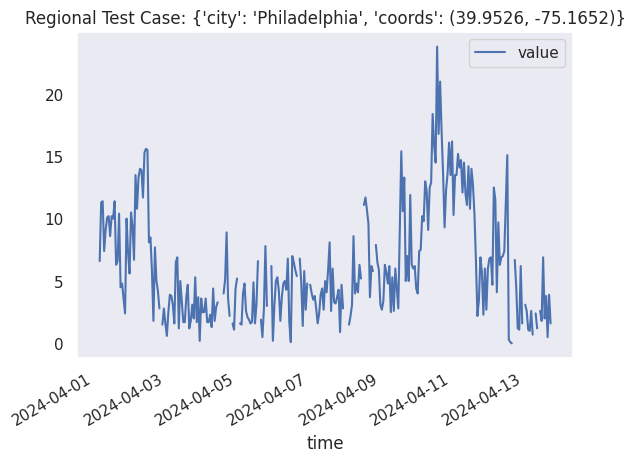


--- Taipei ---
Station: 臺北市 - 萬華 | Sensor ID: 7930492
                     time  value
0    2024-03-31T16:00:00Z   14.0
1    2024-03-31T17:00:00Z   16.0
2    2024-03-31T18:00:00Z   12.0
3    2024-03-31T19:00:00Z   15.0
4    2024-03-31T20:00:00Z   17.0
..                    ...    ...
295  2024-04-13T22:00:00Z   18.0
296  2024-04-13T23:00:00Z   23.0
297  2024-04-14T00:00:00Z   36.0
298  2024-04-14T01:00:00Z   34.0
299  2024-04-14T02:00:00Z   38.0

[300 rows x 2 columns]


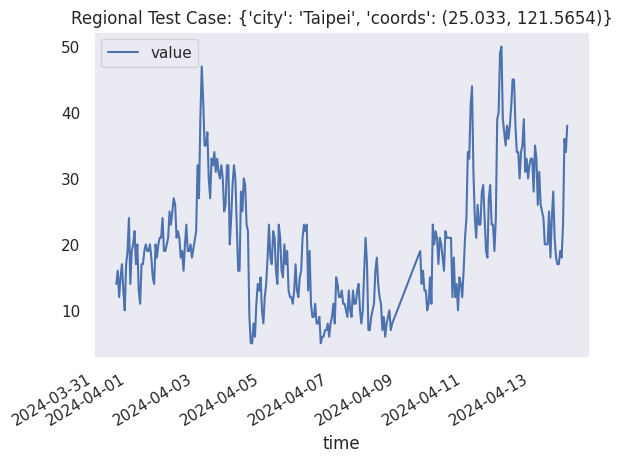


--- Vancouver ---
Station: Kensington Park | Sensor ID: 2156
                     time  value
0    2024-04-01T08:00:00Z    2.0
1    2024-04-01T09:00:00Z    1.9
2    2024-04-01T10:00:00Z    2.4
3    2024-04-01T11:00:00Z    2.9
4    2024-04-01T12:00:00Z    3.1
..                    ...    ...
295  2024-04-13T18:00:00Z    9.9
296  2024-04-13T19:00:00Z   15.4
297  2024-04-13T20:00:00Z   10.1
298  2024-04-13T21:00:00Z    8.2
299  2024-04-13T22:00:00Z    5.4

[300 rows x 2 columns]


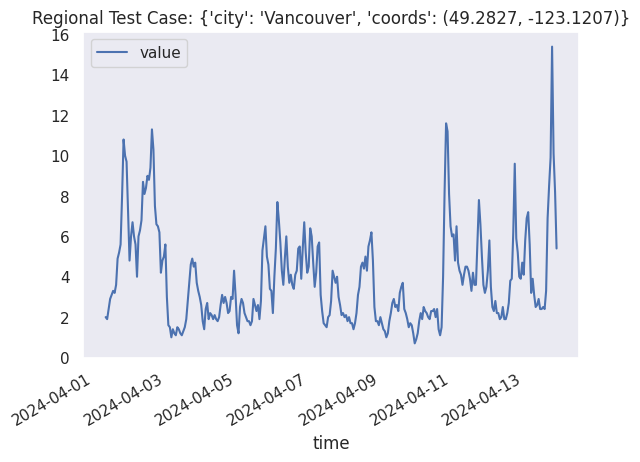

In [ ]:
test_cases = [
    {"city": "Philadelphia", "coords": (39.9526, -75.1652)},
    {"city": "Taipei",  "coords": (25.0330, 121.5654)},
    {"city": "Vancouver",      "coords": (49.2827, -123.1207)}
]

city_dfs = {}

for case in test_cases:
    print(f"\n--- {case['city']} ---")

    # pass to tuples
    locs = api.locations.list(
        coordinates=case["coords"],
        radius=25000,
        parameters_id=2,
        limit=5
    ).results

    if not locs:
        print("No active PM2.5 stations found in this radius.")
        city_dfs[case['city']] = pd.DataFrame() # Store an empty DataFrame
        continue

    station = locs[0]
    pm25_sensor = next(s for s in station.sensors if s.parameter.name == "pm25")
    print(f"Station: {station.name} | Sensor ID: {pm25_sensor.id}")


    meas = api.measurements.list(
        sensors_id=pm25_sensor.id,
        datetime_from="2024-04-01",
        datetime_to="2024-05-01",
        limit=300  # reduced limit to prevent timeouts
    ).results

    df = pd.DataFrame([{
    "time": m.period.datetime_from.utc,
    "value": m.value,
} for m in meas])
    city_dfs[case['city']] = df

    print(df)
    df["time"] = pd.to_datetime(df["time"])
    df.plot(x="time", y="value", kind="line",title=f"Regional Test Case: {case}")
    plt.show()

Philadelphia — MAE: 3.70  RMSE: 5.26 µg/m³
Taipei — MAE: 6.58  RMSE: 8.13 µg/m³
Vancouver — MAE: 1.11  RMSE: 1.60 µg/m³


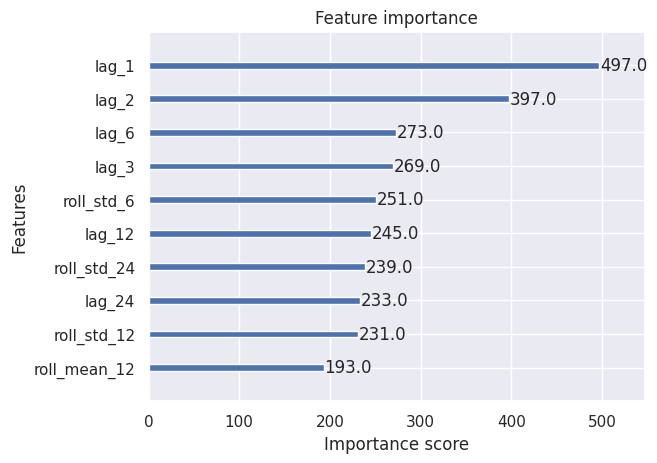

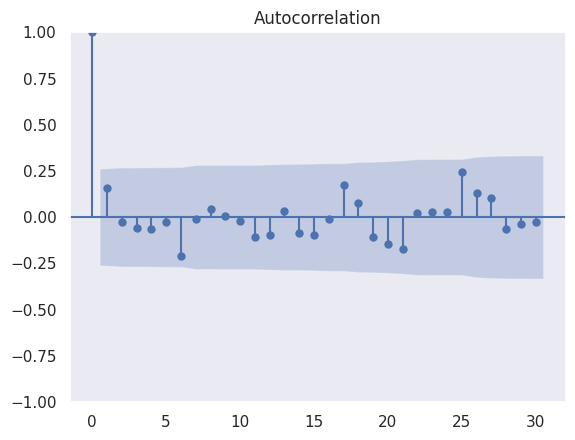

In [ ]:
lags = [1, 2, 3, 6, 12, 24] # time steps
rolls = [6, 12, 24] # trends on specific hours
params = dict(n_estimators=300, max_depth=4, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1) # 80% of rows
# build features
feature_cols = ([f"lag_{l}" for l in lags] +
                [f"roll_mean_{w}" for w in rolls] +
                [f"roll_std_{w}"  for w in rolls] +
                ["hour_sin", "hour_cos", "dayofweek_sin", "dayofweek_cos", "month"])

models = {} # for each city
for city, raw in city_dfs.items():
    if raw.empty: #skip empty dfs
        continue

    df = raw.copy()
    df["time"] = pd.to_datetime(df["time"]) # convert the literal string

    for lag in lags:
        df[f"lag_{lag}"] = df["value"].shift(lag)
    for w in rolls:
        df[f"roll_mean_{w}"] = df["value"].shift(1).rolling(w).mean()
        df[f"roll_std_{w}"]  = df["value"].shift(1).rolling(w).std()
    for col, period in [("hour", 24), ("dayofweek", 7)]:
        df[col] = getattr(df["time"].dt, col)
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period) # wrap around
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)
    df["month"] = df["time"].dt.month
    df.dropna(inplace=True)

    split = int(len(df) * 0.8) # split train and test 80/20
    X_train, X_test = df[feature_cols][:split], df[feature_cols][split:]
    y_train, y_test = df["value"][:split], df["value"][split:]

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)
    models[city] = model

    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    print(f"{city} — MAE: {mae:.2f}  RMSE: {rmse:.2f} µg/m³")

plot_importance(model, max_num_features=10)
plt.show()

# autocorrelation/gaussian white noise
residuals = y_test - preds
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.show()